# Adversarial Transferability on MNIST: Attacking a Black-Box API with a Substitute Model

**Objective.** Show that adversarial examples crafted against a model you fully control (the **substitute**) often fool a *different* model that you can only **query** (the **target**, standing in for a model hosted behind a website or third-party API), even though the two models have different architectures and were trained on different data.

## What you will do

1. Load MNIST and give the two models different data: the target (API-side) model gets the MNIST **training** set, the substitute (local) model gets the MNIST **test** set. Hold out 10% of each for evaluation.
2. Define two different architectures, a CNN for the target and an MLP for the substitute, and train both to high accuracy.
3. Hide the target behind a query-only API that returns nothing but logits and probabilities.
4. Run the white-box PGD attack, with the Adversarial Robustness Toolbox (ART), against the substitute.
5. Pick 10 adversarial samples that successfully fooled the substitute, plot the logits and probabilities before and after the attack, then send them to the API and count how many fool it too.
6. Measure the cross-architecture **transfer fooling rate** over the whole held-out set and across attack strengths.
7. Articulate how MI-FGSM and input diversity improve transfer success over vanilla FGSM.

## Prerequisites

- Comfortable with CNNs and MLPs, cross-entropy loss, logits vs. probabilities (softmax), and the L-infinity norm.
- Familiar with the white-box PGD attack. Transferability is what lets a white-box attack be used against a model you cannot differentiate.

## Running this notebook

This is a self-contained notebook: it downloads MNIST, trains both models, and simulates the black-box API locally, so no external model or dataset files are required. Run the cells top to bottom, on Colab or locally. A GPU is not required.

## Background: transferability and substitute models

**The transferability phenomenon.** An adversarial example crafted against model A is often misclassified by a different model B, even when B has a different architecture and was trained on different data. This is what makes black-box attacks practical: an attacker who cannot compute gradients of the target computes them on a model they own and hopes the result carries over.

Two main hypotheses explain why it works:

- **Shared features.** Models trained on the same task learn similar *non-robust* features: patterns that genuinely correlate with the label but that humans ignore. A perturbation that flips the substitute by disturbing such a feature also flips any model that relies on the same feature.
- **Aligned decision boundaries.** Around a given input, the decision boundaries of models trained on the same data distribution lie in similar places, and the low-dimensional subspaces of adversarial directions of different models overlap substantially. Crossing the substitute's boundary along a gradient direction therefore tends to cross the target's boundary too.

**Architecture matters.** Transfer is usually highest between similar architectures (CNN to CNN) and lower across model families (CNN to MLP), because different inductive biases mean different reliance on features. This lab deliberately uses a CNN target and an MLP substitute, the harder cross-architecture case.

**The substitute-model attack.** The attacker cannot see the target's weights or training data, so they:

1. gather some data from the same domain,
2. train a *substitute* model on it (in the classic attack the labels are **synthetic labels** obtained by querying the target; you will try this in the assignment),
3. run a strong **white-box** attack (here PGD) on the substitute,
4. send the resulting adversarial examples to the target and check whether they transfer.

| | Target (API side) | Substitute (local) |
|---|---|---|
| Architecture | CNN: 3 conv + 2 dense layers | MLP: 3 dense layers |
| Training data | MNIST training set (60,000) | MNIST test set (10,000) |
| What the attacker can do | Query only: send images, receive logits and probabilities | Everything: read weights, compute gradients |

## 1. Setup

Install the Adversarial Robustness Toolbox (ART), then import the libraries. PyTorch, torchvision, NumPy, and Matplotlib are usually already available (e.g. on Colab); ART is not, so we install it here.

In [1]:
# ART (Adversarial Robustness Toolbox) provides the PGD attack.
# PyTorch, torchvision, and Matplotlib are usually pre-installed (e.g. on Colab);
# uncomment the second line if your environment is missing them.
!pip install adversarial-robustness-toolbox
# !pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

# ART components used in this notebook:
# - PyTorchClassifier wraps a PyTorch model in ART's estimator interface.
# - ProjectedGradientDescent is the PGD evasion attack.
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


## 2. Load and prepare the data

The two models never see the same data. The **target** is trained on the MNIST training set (60,000 images) and the **substitute** on the MNIST test set (10,000 images), which mimics an attacker who has *some* data from the right domain but not the API owner's training set. We normalize pixels to `[0, 1]`, add a channel axis, and hold out **10%** of each model's data for evaluation (`EVAL_FRACTION = 0.1`).

The substitute's held-out split (1,000 images) is special: neither model trained on it, so it is where we will craft and test the adversarial examples.

In [3]:
# Download MNIST, scale pixels from [0, 255] to [0, 1], add a channel axis: (N, 28, 28) -> (N, 1, 28, 28).
mnist_train = datasets.MNIST(root='data', train=True, download=True)
mnist_test = datasets.MNIST(root='data', train=False, download=True)

def prepare(ds):
    x = ds.data.numpy().astype('float32')[:, None, :, :] / 255.0
    y = ds.targets.numpy().astype('int64')
    return x, y

x_target_all, y_target_all = prepare(mnist_train)   # 60,000 images -> target (API-side) model
x_sub_all, y_sub_all = prepare(mnist_test)          # 10,000 images -> substitute (local) model

EVAL_FRACTION = 0.1   # hold out 10% of each model's data for evaluation

def split(x, y, frac, seed):
    idx = np.random.default_rng(seed).permutation(len(x))
    n_eval = int(len(x) * frac)
    return x[idx[n_eval:]], y[idx[n_eval:]], x[idx[:n_eval]], y[idx[:n_eval]]

x_t_tr, y_t_tr, x_t_ev, y_t_ev = split(x_target_all, y_target_all, EVAL_FRACTION, SEED)
x_s_tr, y_s_tr, x_s_ev, y_s_ev = split(x_sub_all, y_sub_all, EVAL_FRACTION, SEED)

print(f"Target     train: {x_t_tr.shape}  eval: {x_t_ev.shape}")
print(f"Substitute train: {x_s_tr.shape}  eval: {x_s_ev.shape}")
print("pixel range:", (float(x_t_tr.min()), float(x_t_tr.max())))

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.23MB/s]


Target     train: (54000, 1, 28, 28)  eval: (6000, 1, 28, 28)
Substitute train: (9000, 1, 28, 28)  eval: (1000, 1, 28, 28)
pixel range: (0.0, 1.0)


### A quick look at the clean data

Sanity-check the inputs: one clean example per digit class from the substitute's training data.

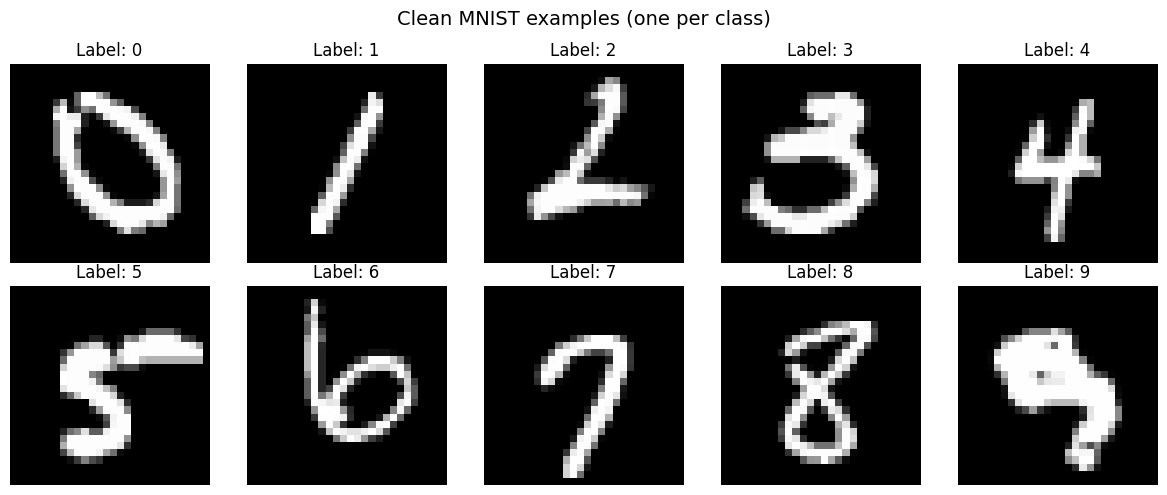

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_s_tr == i)[0][0]
    ax.imshow(x_s_tr[idx].squeeze(), cmap='gray_r')
    ax.set_title(f"Label: {i}", fontsize=12)
    ax.axis('off')
fig.suptitle("Clean MNIST examples (one per class)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Define the two architectures

Two deliberately different model families. Both output raw **logits** (the scores before softmax); probabilities are obtained with a softmax afterwards. Keeping logits available is what lets us plot them later.

- **Target: `TargetCNN`.** Three convolution+pooling blocks followed by two dense layers. Convolutions share weights across positions and look at local patterns.
- **Substitute: `SubstituteMLP`.** Three fully connected layers on the flattened pixels. It has no notion of spatial locality, so it sees the image very differently from the CNN.

In [5]:
class TargetCNN(nn.Module):
    # 3 conv blocks + 2 dense layers (the API-side model).
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),     # 28 -> 26 -> 13
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),    # 13 -> 11 -> 5
            nn.Conv2d(64, 128, 3), nn.ReLU(), nn.MaxPool2d(2),   # 5 -> 3 -> 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))   # logits


class SubstituteMLP(nn.Module):
    # 3 fully connected layers on flattened pixels (the attacker's local model).
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)   # logits


target_model = TargetCNN().to(device)
substitute = SubstituteMLP().to(device)
n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"TargetCNN     parameters: {n_params(target_model):,}")
print(f"SubstituteMLP parameters: {n_params(substitute):,}")

TargetCNN     parameters: 110,474
SubstituteMLP parameters: 235,146


## 4. Train both models

Each model trains on its own data with the same recipe (Adam, cross-entropy on logits). The accuracy on each model's own 10% held-out split confirms that both are strong classifiers, so any later drop in accuracy can be attributed to the attack and not to weak training.

In [6]:
def train(model, x, y, epochs, batch_size=128, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y)),
                        batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        model.train()
        total, correct, running = 0, 0, 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(xb)
        print(f"  epoch {epoch + 1}/{epochs}  loss {running / total:.4f}  train acc {correct / total:.4f}")
    model.eval()

@torch.no_grad()
def accuracy(model, x, y):
    model.eval()
    logits = model(torch.from_numpy(x).to(device))
    return (logits.argmax(1).cpu().numpy() == y).mean()

print("Training the target CNN on the MNIST training set...")
train(target_model, x_t_tr, y_t_tr, epochs=8)
print("\nTraining the substitute MLP on the MNIST test set...")
train(substitute, x_s_tr, y_s_tr, epochs=20, batch_size=64)

print(f"\nTarget     (CNN) held-out accuracy: {accuracy(target_model, x_t_ev, y_t_ev) * 100:.2f}%")
print(f"Substitute (MLP) held-out accuracy: {accuracy(substitute, x_s_ev, y_s_ev) * 100:.2f}%")

Training the target CNN on the MNIST training set...
  epoch 1/8  loss 0.4161  train acc 0.8721
  epoch 2/8  loss 0.1145  train acc 0.9659
  epoch 3/8  loss 0.0795  train acc 0.9751
  epoch 4/8  loss 0.0651  train acc 0.9800
  epoch 5/8  loss 0.0515  train acc 0.9848
  epoch 6/8  loss 0.0440  train acc 0.9861
  epoch 7/8  loss 0.0361  train acc 0.9889
  epoch 8/8  loss 0.0321  train acc 0.9902

Training the substitute MLP on the MNIST test set...
  epoch 1/20  loss 0.6504  train acc 0.8214
  epoch 2/20  loss 0.2538  train acc 0.9264
  epoch 3/20  loss 0.1786  train acc 0.9473
  epoch 4/20  loss 0.1314  train acc 0.9597
  epoch 5/20  loss 0.0924  train acc 0.9736
  epoch 6/20  loss 0.0661  train acc 0.9818
  epoch 7/20  loss 0.0484  train acc 0.9861
  epoch 8/20  loss 0.0354  train acc 0.9896
  epoch 9/20  loss 0.0243  train acc 0.9946
  epoch 10/20  loss 0.0159  train acc 0.9966
  epoch 11/20  loss 0.0136  train acc 0.9971
  epoch 12/20  loss 0.0108  train acc 0.9980
  epoch 13/20  los

## 5. Put the target behind a black-box API

From this point on the target is a **query oracle**, like a model on a website or a third-party service. `BlackBoxAPI` accepts images and returns only **logits** and **probabilities**; the attacker never touches its weights or gradients. We also count queries, since query volume is what an API owner can monitor.

We then `del` the direct reference to the target model so the rest of the notebook cannot accidentally use it.

In [7]:
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


class BlackBoxAPI:
    # Mimics a hosted model: send images in, get logits and probabilities back. Nothing else.
    def __init__(self, model):
        self._model = model.eval()
        self.query_count = 0

    @torch.no_grad()
    def query(self, x):
        self.query_count += len(x)
        logits = self._model(torch.as_tensor(x, dtype=torch.float32, device=device)).cpu().numpy()
        return logits, softmax(logits)


api = BlackBoxAPI(target_model)
del target_model   # the attacker only has the API from here on

logits, probs = api.query(x_s_ev)
print(f"API accuracy on the attacker's held-out images: {(logits.argmax(1) == y_s_ev).mean() * 100:.2f}%")
print("Queries used so far:", api.query_count)

API accuracy on the attacker's held-out images: 98.40%
Queries used so far: 1000


## 6. Attack the substitute with PGD

### Wrap the substitute for ART

ART attacks operate on an *estimator*, not a raw PyTorch model. We wrap the **substitute** (the model we own) with `PyTorchClassifier` and declare the valid pixel range via `clip_values=(0.0, 1.0)`. The attack computes exact gradients on this model. The target API is never wrapped or differentiated.

In [8]:
substitute_clf = PyTorchClassifier(
    model=substitute,
    loss=nn.CrossEntropyLoss(),
    input_shape=(1, 28, 28),
    nb_classes=10,
    clip_values=(0.0, 1.0),
    device_type='gpu' if torch.cuda.is_available() else 'cpu',
)

### Build and run the attack

PGD's behavior is set by three parameters:

| Parameter | Role |
|-----------|------|
| `eps` | L-infinity perturbation budget: the maximum change per pixel on the `[0, 1]` scale. We use `0.3`, the standard budget for MNIST. |
| `eps_step` | Step size per iteration. We use `eps / 10`. |
| `max_iter` | Number of gradient-ascent + projection iterations (here `40`). |

We attack the substitute's 1,000 held-out images. The labels passed in are the **true** labels, so the attack pushes each image away from its correct class.

In [9]:
EPS = 0.3
attack_pgd = ProjectedGradientDescent(
    estimator=substitute_clf,
    norm=np.inf,
    eps=EPS,
    eps_step=EPS / 10,
    max_iter=40,
    num_random_init=1,
    verbose=False,
)

y_s_ev_onehot = np.eye(10, dtype='float32')[y_s_ev]
x_s_ev_adv = attack_pgd.generate(x=x_s_ev, y=y_s_ev_onehot)

sub_pred_clean = substitute_clf.predict(x_s_ev).argmax(1)
sub_pred_adv = substitute_clf.predict(x_s_ev_adv).argmax(1)
print(f"Substitute accuracy, clean:       {(sub_pred_clean == y_s_ev).mean() * 100:5.2f}%")
print(f"Substitute accuracy, adversarial: {(sub_pred_adv == y_s_ev).mean() * 100:5.2f}%   (white-box: the attack was built on this model)")
print(f"L-infinity norm of the perturbation: {np.abs(x_s_ev_adv - x_s_ev).max():.3f}  (should be <= eps = {EPS})")

Substitute accuracy, clean:       95.90%
Substitute accuracy, adversarial:  0.00%   (white-box: the attack was built on this model)
L-infinity norm of the perturbation: 0.300  (should be <= eps = 0.3)


## 7. Pick 10 successful adversarial samples

We now choose **10 samples** to study closely. To make the experiment meaningful, each sample must satisfy three conditions:

1. the substitute classifies the **clean** image correctly,
2. the API also classifies the **clean** image correctly (so a wrong answer on the adversarial image is caused by the attack, not by a hard image),
3. the PGD example **successfully fools the substitute** (the white-box attack worked).

Nothing is filtered on whether the API is fooled: that is what we are about to measure. The 10 samples are drawn at random (with a fixed seed) from all images meeting the conditions.

> In this lab we query the API on the whole held-out set only to *measure* transfer rates. A real attacker needs queries only to check whether an adversarial example worked.

In [10]:
api_pred_clean = api.query(x_s_ev)[0].argmax(1)

ok = (sub_pred_clean == y_s_ev) & (api_pred_clean == y_s_ev) & (sub_pred_adv != y_s_ev)
candidates = np.flatnonzero(ok)
print(f"{len(candidates)} of {len(x_s_ev)} held-out images qualify (correct on both models, PGD fooled the substitute)")

rng = np.random.default_rng(SEED)
chosen = np.sort(rng.choice(candidates, size=10, replace=False))
x_sel, x_sel_adv, y_sel = x_s_ev[chosen], x_s_ev_adv[chosen], y_s_ev[chosen]
print("Chosen indices:", chosen.tolist())
print("True labels:   ", y_sel.tolist())

950 of 1000 held-out images qualify (correct on both models, PGD fooled the substitute)
Chosen indices: [17, 41, 75, 174, 269, 307, 507, 632, 813, 842]
True labels:    [7, 2, 9, 7, 2, 3, 1, 7, 2, 4]


### The 10 samples, before and after the attack

Top row: the clean images. Bottom row: their PGD versions. Titles show the true digit and the substitute's prediction (green = correct, red = wrong).

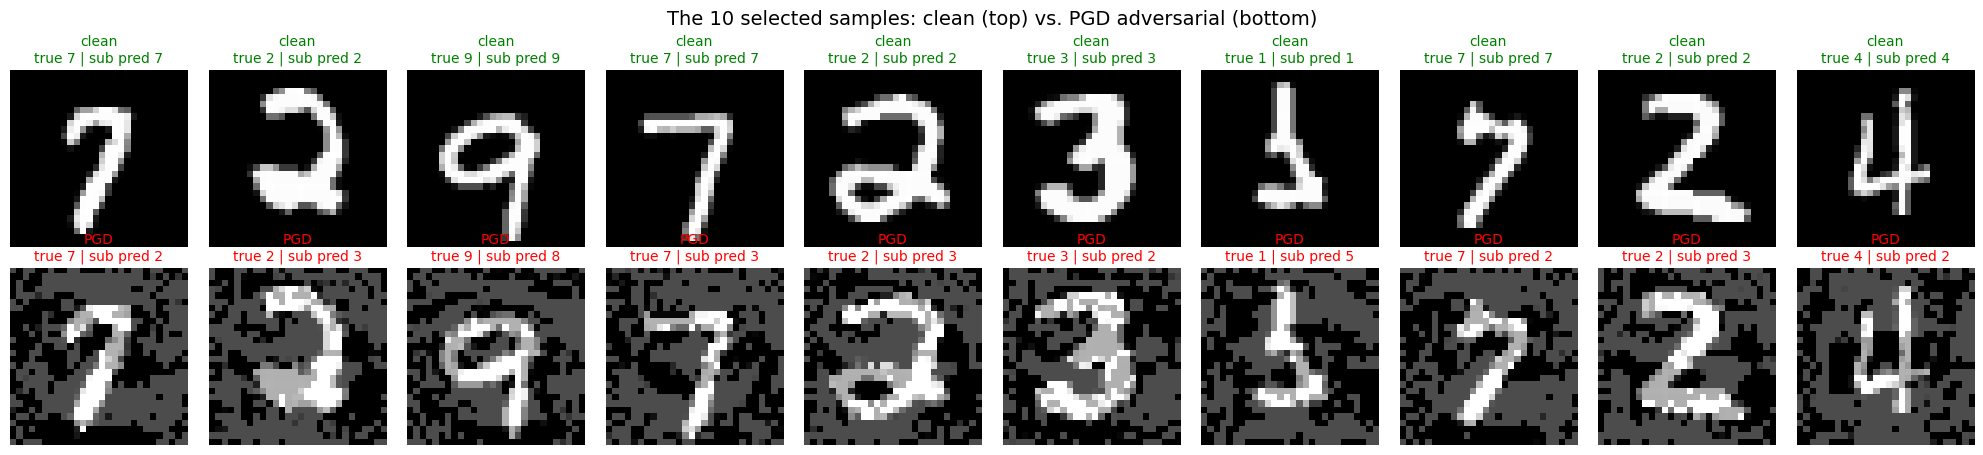

In [11]:
sub_logits_clean = substitute_clf.predict(x_sel)
sub_logits_adv = substitute_clf.predict(x_sel_adv)

fig, axes = plt.subplots(2, 10, figsize=(20, 4.6))
for k in range(10):
    for row, (imgs, logits, name) in enumerate([(x_sel, sub_logits_clean, 'clean'), (x_sel_adv, sub_logits_adv, 'PGD')]):
        pred = logits[k].argmax()
        axes[row, k].imshow(imgs[k].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, k].set_title(f"{name}\ntrue {y_sel[k]} | sub pred {pred}", fontsize=10,
                               color='green' if pred == y_sel[k] else 'red')
        axes[row, k].axis('off')
fig.suptitle("The 10 selected samples: clean (top) vs. PGD adversarial (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Logits and probabilities: before attack, after attack, and on the API

Each heatmap has one row per selected sample and one column per digit class. A **green** box marks the model's predicted class when it is correct, a **red** box when it is wrong.

- **Panels 1 and 2** show our own substitute *before* and *after* the attack. Since the samples were chosen to fool it, panel 2 must show red boxes everywhere.
- **Panels 3 and 4** show the black-box API on the same clean and adversarial images. This is the transfer test: red boxes in panel 4 are samples that fooled a model we never differentiated.

Logits are the raw scores; probabilities are their softmax.

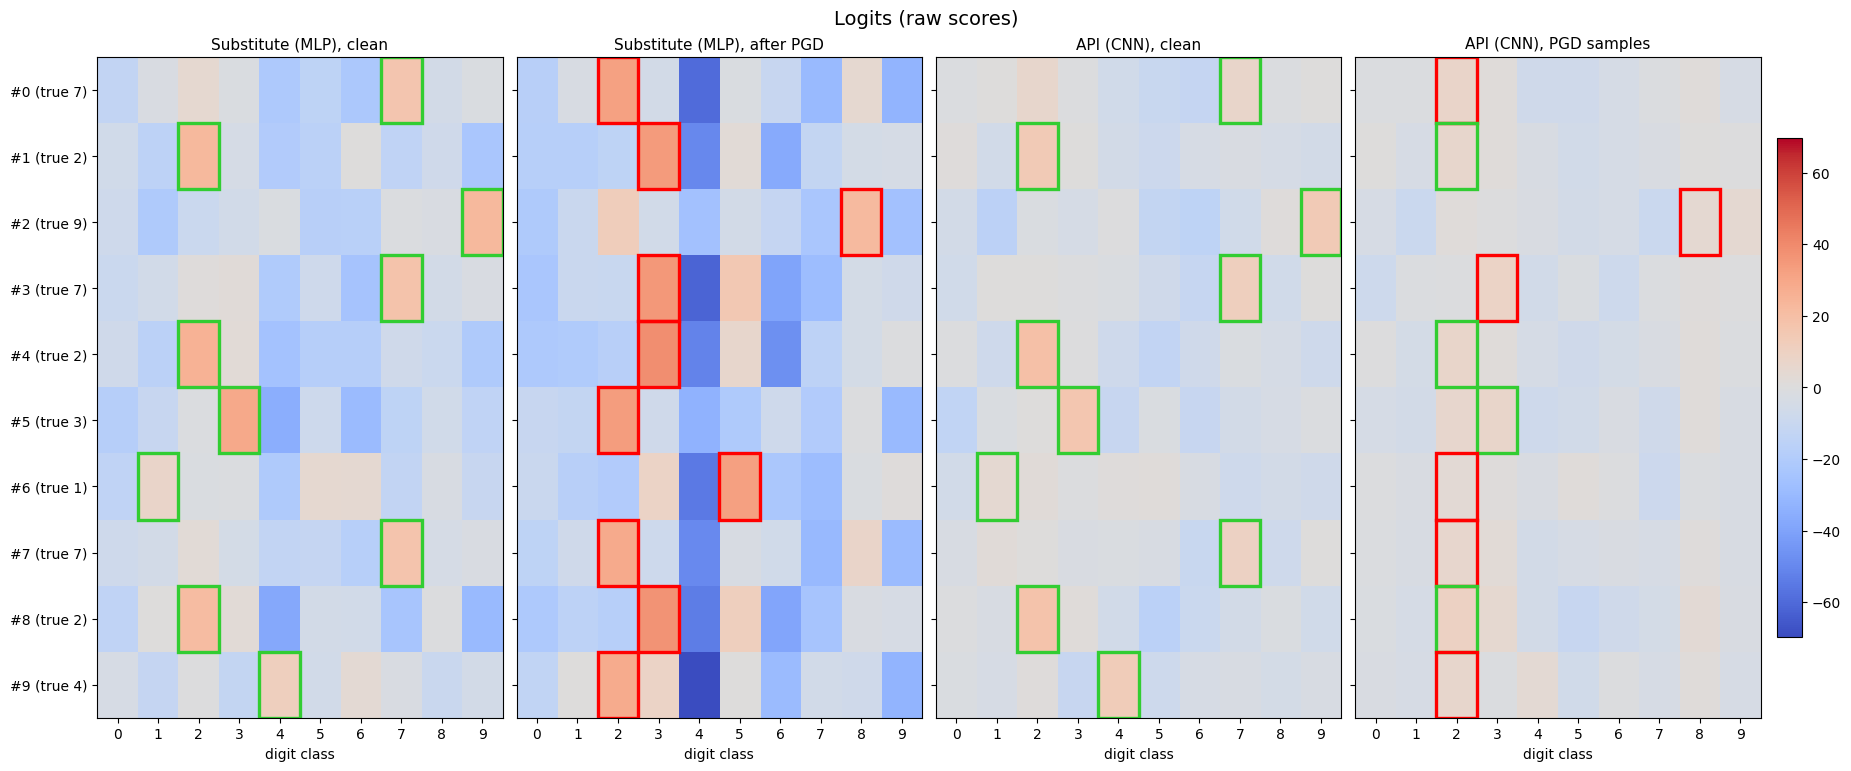

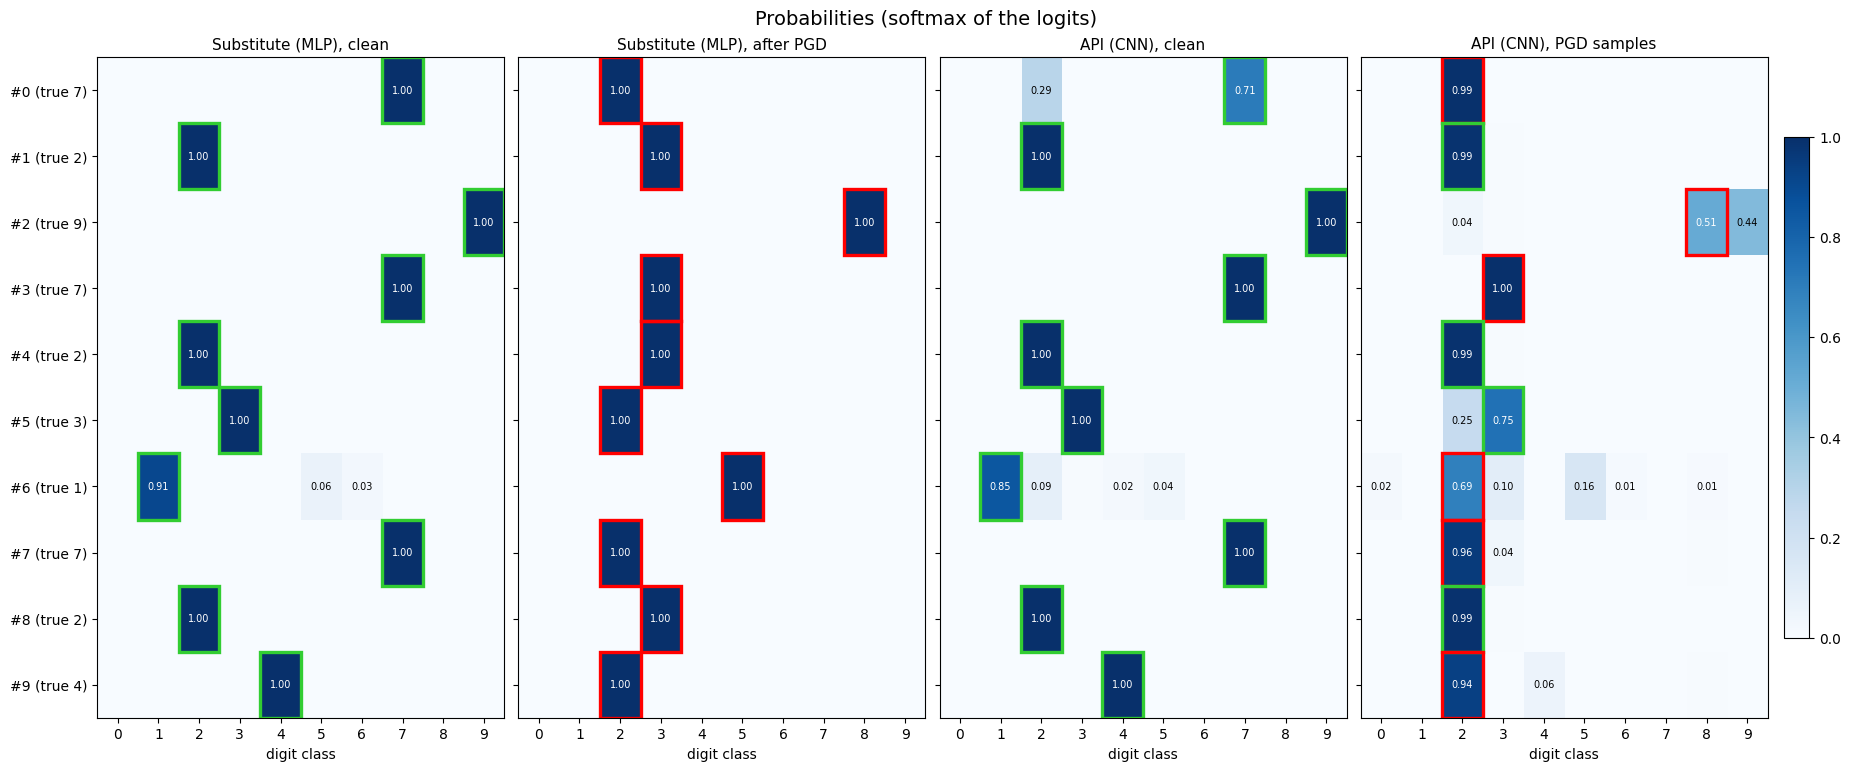

In [12]:
api_logits_clean, api_probs_clean = api.query(x_sel)
api_logits_adv, api_probs_adv = api.query(x_sel_adv)

def plot_heatmaps(panels, true_labels, title, cmap, annotate=False, vmin=None, vmax=None):
    n = len(true_labels)
    fig, axes = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 0.5 * n + 2.6),
                             sharey=True, constrained_layout=True)
    for ax, (name, mat) in zip(axes, panels):
        im = ax.imshow(mat, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
        pred = mat.argmax(axis=1)
        for i in range(n):
            correct = pred[i] == true_labels[i]
            ax.add_patch(Rectangle((pred[i] - 0.5, i - 0.5), 1, 1, fill=False, lw=2.4,
                                   ec='limegreen' if correct else 'red'))
            if annotate:
                for c in range(mat.shape[1]):
                    if mat[i, c] >= 0.01:
                        ax.text(c, i, f"{mat[i, c]:.2f}", ha='center', va='center', fontsize=7,
                                color='white' if mat[i, c] > 0.5 else 'black')
        ax.set_xticks(range(10))
        ax.set_xlabel('digit class')
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"#{k} (true {t})" for k, t in enumerate(true_labels)])
        ax.set_title(name, fontsize=11)
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
    fig.suptitle(title, fontsize=14)
    plt.show()

# Logits: shared symmetric colour scale so the four panels are comparable.
lim = max(np.abs(a).max() for a in (sub_logits_clean, sub_logits_adv, api_logits_clean, api_logits_adv))
plot_heatmaps(
    [("Substitute (MLP), clean", sub_logits_clean), ("Substitute (MLP), after PGD", sub_logits_adv),
     ("API (CNN), clean", api_logits_clean), ("API (CNN), PGD samples", api_logits_adv)],
    y_sel, "Logits (raw scores)", cmap='coolwarm', vmin=-lim, vmax=lim)

plot_heatmaps(
    [("Substitute (MLP), clean", softmax(sub_logits_clean)), ("Substitute (MLP), after PGD", softmax(sub_logits_adv)),
     ("API (CNN), clean", api_probs_clean), ("API (CNN), PGD samples", api_probs_adv)],
    y_sel, "Probabilities (softmax of the logits)", cmap='Blues', annotate=True, vmin=0, vmax=1)

### Did the samples transfer?

For every selected sample: the substitute's prediction before and after the attack, the API's prediction before and after, and whether the API was fooled. The API's **confidence in the true class** shows how far the attack pushed it, even for samples that did not fully flip the prediction.

In [13]:
api_pred_sel_clean = api_probs_clean.argmax(1)
api_pred_sel_adv = api_probs_adv.argmax(1)
sub_pred_sel_adv = sub_logits_adv.argmax(1)

print(f"{'#':>2} {'true':>4} | {'substitute: clean -> adv':>25} | {'API: clean -> adv':>19} | {'API P(true) clean -> adv':>26} | API fooled?")
for k in range(10):
    fooled = api_pred_sel_adv[k] != y_sel[k]
    print(f"{k:>2} {y_sel[k]:>4} | {sub_logits_clean[k].argmax():>11} -> {sub_pred_sel_adv[k]:<10} | "
          f"{api_pred_sel_clean[k]:>8} -> {api_pred_sel_adv[k]:<8} | "
          f"{api_probs_clean[k, y_sel[k]]:>11.3f} -> {api_probs_adv[k, y_sel[k]]:<9.3f} | {'YES' if fooled else 'no'}")

n_fooled = int((api_pred_sel_adv != y_sel).sum())
print(f"\nThe substitute was fooled on 10 / 10 samples (by construction).")
print(f"The black-box API was fooled on {n_fooled} / 10 samples  ->  transfer rate on this sample = {n_fooled * 10}%")
print("Total API queries used:", api.query_count)

 # true |  substitute: clean -> adv |   API: clean -> adv |   API P(true) clean -> adv | API fooled?
 0    7 |           7 -> 2          |        7 -> 2        |       0.708 -> 0.000     | YES
 1    2 |           2 -> 3          |        2 -> 2        |       1.000 -> 0.985     | no
 2    9 |           9 -> 8          |        9 -> 8        |       1.000 -> 0.444     | YES
 3    7 |           7 -> 3          |        7 -> 3        |       1.000 -> 0.000     | YES
 4    2 |           2 -> 3          |        2 -> 2        |       1.000 -> 0.990     | no
 5    3 |           3 -> 2          |        3 -> 3        |       1.000 -> 0.747     | no
 6    1 |           1 -> 5          |        1 -> 2        |       0.849 -> 0.004     | YES
 7    7 |           7 -> 2          |        7 -> 2        |       0.999 -> 0.000     | YES
 8    2 |           2 -> 3          |        2 -> 2        |       1.000 -> 0.991     | no
 9    4 |           4 -> 2          |        4 -> 2        |       1.000 ->

## 9. Transfer fooling rate over the whole held-out set

Ten samples are a good story but a noisy statistic. To measure the cross-architecture transfer fooling rate properly, we repeat the experiment on all held-out images, restricted to the ones both models classify correctly when clean. We report:

- **White-box fooling rate:** the fraction of those images whose PGD version fools the substitute.
- **Transfer rate:** among the images that fooled the substitute, the fraction that *also* fool the API. This is the standard definition of transferability.
- **API error rate:** the fraction of all those adversarial images the API gets wrong (transfer rate weighted by the white-box success).

We then sweep the perturbation budget `eps` to see how transfer grows with attack strength.

In [14]:
valid = (sub_pred_clean == y_s_ev) & (api_pred_clean == y_s_ev)

def transfer_stats(x_adv):
    sub_wrong = valid & (substitute_clf.predict(x_adv).argmax(1) != y_s_ev)
    api_wrong = valid & (api.query(x_adv)[0].argmax(1) != y_s_ev)
    return {
        'white_box': sub_wrong.sum() / valid.sum(),
        'transfer': (sub_wrong & api_wrong).sum() / max(sub_wrong.sum(), 1),
        'api_error': api_wrong.sum() / valid.sum(),
    }

stats = transfer_stats(x_s_ev_adv)
print(f"Images correct on both models when clean: {valid.sum()} / {len(valid)}")
print(f"White-box fooling rate (substitute): {stats['white_box'] * 100:5.1f}%")
print(f"Transfer rate (API fooled | substitute fooled): {stats['transfer'] * 100:5.1f}%")
print(f"API error rate on the adversarial images:       {stats['api_error'] * 100:5.1f}%")

Images correct on both models when clean: 950 / 1000
White-box fooling rate (substitute): 100.0%
Transfer rate (API fooled | substitute fooled):  45.6%
API error rate on the adversarial images:        45.6%


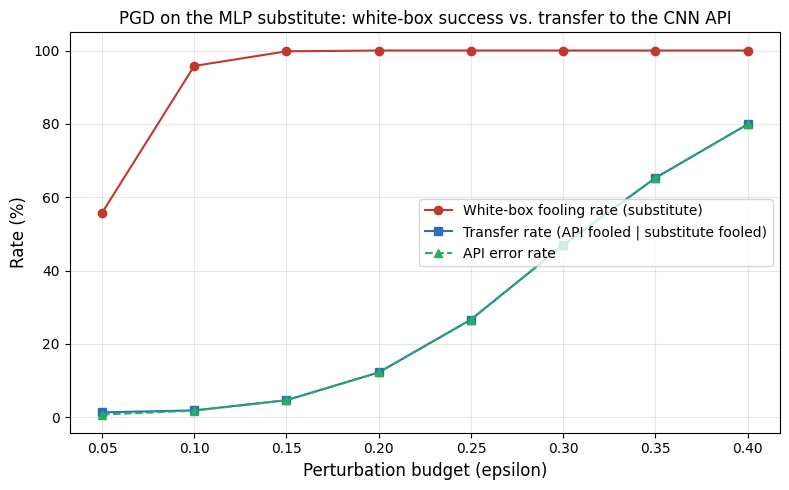

In [15]:
# Sweep the perturbation budget: how does transfer grow with attack strength?
eps_range = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
sweep = []
for eps in eps_range:
    attack_pgd.set_params(eps=eps, eps_step=eps / 10)
    sweep.append(transfer_stats(attack_pgd.generate(x=x_s_ev, y=y_s_ev_onehot)))
attack_pgd.set_params(eps=EPS, eps_step=EPS / 10)   # restore the main attack settings

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_range, [s['white_box'] * 100 for s in sweep], marker='o', color='#c0392b', label='White-box fooling rate (substitute)')
ax.plot(eps_range, [s['transfer'] * 100 for s in sweep], marker='s', color='#2c6fbb', label='Transfer rate (API fooled | substitute fooled)')
ax.plot(eps_range, [s['api_error'] * 100 for s in sweep], marker='^', color='#27ae60', linestyle='--', label='API error rate')
ax.set_xlabel('Perturbation budget (epsilon)', fontsize=12)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title('PGD on the MLP substitute: white-box success vs. transfer to the CNN API', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

> **Takeaway.** The transfer curve stays below the white-box curve: the gap between them is the part of the perturbation that is specific to the substitute and does not carry over to the CNN. Transfer is real, since an attack built without any access to the API's weights fools it, but it needs a larger budget than the white-box attack does.

## 10. Boosting transferability: MI-FGSM and input diversity

The gap you just measured, strong white-box success but weaker transfer, has a name: the attack **overfits the substitute**. Dong et al. (2018) framed crafting an adversarial example as an *optimization problem* that behaves like training a model:

| Attack | Analogy | What happens |
|---|---|---|
| **Vanilla FGSM** (one step) | *Underfitting* | One linear step is a crude approximation of the loss surface, so it often fails to fool even the substitute. What does succeed does so with a coarse, generic direction. |
| **Iterative FGSM / PGD** (many steps) | *Overfitting* | It follows the substitute's loss surface very closely, so it succeeds on the substitute (near 100% above) but exploits quirks of that one model, and transfers less than its white-box strength suggests. |
| **MI-FGSM, input diversity** | *Regularizing the attack* | Keep the strength of the iterative attack but stop it from overfitting, so more of the perturbation is model-independent. |

**MI-FGSM (momentum iterative FGSM).** Instead of following the current gradient alone, it accumulates a velocity vector across iterations, exactly like momentum in SGD:

$$g_{t+1} = \mu \, g_t + \frac{\nabla_x L(x_t^{adv}, y)}{\lVert \nabla_x L(x_t^{adv}, y) \rVert_1}, \qquad x_{t+1}^{adv} = \mathrm{clip}_{x,\epsilon}\big(x_t^{adv} + \alpha \cdot \mathrm{sign}(g_{t+1})\big)$$

with decay factor $\mu \approx 1$. Why it helps transfer:

- The gradient of a single model is noisy and its direction can oscillate between iterations. Summing normalized gradients keeps the update pointing along directions that are **consistently** good, which are the ones more likely to be useful to other models too.
- Momentum lets the attack **escape poor local maxima** of the substitute's loss instead of settling into a narrow, model-specific one.
- The result: it matches the white-box strength of iterative FGSM but stabilizes the update direction, which transfers substantially better than vanilla FGSM and plain I-FGSM in black-box tests.

**Input diversity (DI-FGSM).** At every iteration, before computing the gradient, the current adversarial image is passed through a **random transformation** $T(\cdot\,; p)$ (a random resize followed by random padding), applied with probability $p$:

$$x_{t+1}^{adv} = \mathrm{clip}_{x,\epsilon}\big(x_t^{adv} + \alpha \cdot \mathrm{sign}\big(\nabla_x L(T(x_t^{adv}; p), y)\big)\big)$$

Why it helps transfer:

- It is **data augmentation for the attack**. Just as augmenting training data reduces a model's overfitting, augmenting the attack's input prevents the perturbation from over-relying on exact pixel positions and on the substitute's idiosyncrasies. The perturbation must fool many transformed views of the image, so it is more likely to survive the differences in a different model.
- It costs nothing at test time: the transformation is only used while crafting, and the final adversarial image is unchanged in shape.

**Together.** The two ideas are complementary (momentum stabilizes *direction across iterations*, diversity varies the *input at each iteration*) and combine as M-DI-FGSM. A third booster, **translation invariance (TI-FGSM)**, smooths the gradient with a Gaussian kernel so the perturbation depends less on the exact location of the features each model finds discriminative.

**Connect it to your results.** Look at the sweep above: the distance between the white-box and transfer curves is exactly the overfitting these methods attack. Plain PGD here is the strong-but-overfit iterative baseline; MI-FGSM and input diversity aim to raise the transfer curve without lowering the white-box one.

## Key takeaways

- **Adversarial examples transfer across architectures.** PGD examples crafted on an MLP that never saw the API's weights or training data fool a CNN behind a query-only interface, because the two models rely on overlapping non-robust features and have aligned decision boundaries.
- **Black-box access is not safety.** The attacker needed the API only to check the result. The gradients came from a model they trained themselves on their own data.
- **Transfer is weaker than white-box success.** Iterative attacks overfit the substitute, so the transfer rate sits below the white-box fooling rate.
- **Boosters close the gap.** Momentum (MI-FGSM) stabilizes the update direction and input diversity augments the attack, both trading nothing in white-box strength for better transfer over vanilla FGSM.
- **Diversity of the substitute matters too.** Transfer depends on how similar the substitute and target are; a substitute trained on labels obtained by querying the target (as in the classic substitute attack) aligns with it even more closely.

## Assignment

Complete each item directly in this notebook, re-running from that point forward.

1. Using the two hypotheses (shared features, aligned decision boundaries), explain why PGD examples built on the MLP transfer to the CNN at all, even though the two models have different architectures and training data.
2. Change the substitute's architecture (add or remove a hidden layer, or replace it with a small CNN), retrain, and report whether the transfer rate at `EPS = 0.3` rose or fell.
3. Set `EPS = 0.15`, re-run the attack, and report the white-box fooling rate, the transfer rate, and how many of the 10 selected samples fool the API.
4. Replace PGD with ART's `FastGradientMethod` at the same `eps`, and compare white-box and transfer rates. Which one transfers better relative to its white-box success, and how does that connect to MI-FGSM and input diversity?
5. Substitute training by querying: retrain the substitute using the API's predicted labels (`api.query(x_s_tr)[0].argmax(1)`) instead of the true labels, and report the new transfer rate.
6. **(General knowledge.)** Would hiding the logits and probabilities and returning only the top-1 label protect an API against this attack? Why or why not?

You have completed this lab when you have answered 1 and 6, and reported your findings for 2-5.